In [12]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [13]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [14]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-10'

In [15]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_84TeV_haaexcl'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [16]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [17]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [18]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [19]:
# ok now I want to plot b-jets and photons variables
selection = {
    'nocuts' : "All events",
    "lep_channel" : "Photon and $b$-jet sel, $\geq 1$ lepton",
    "pT_yy_bin1" : "0$\leq p_{T}(\gamma\gamma)$< 60 GeV",
    "pT_yy_bin2" : "60$\leq p_{T}(\gamma\gamma)$< 120 GeV",
    "pT_yy_bin3" : "120$\leq p_{T}(\gamma\gamma)$< 200 GeV",
    "pT_yy_bin4" : "200$\leq p_{T}(\gamma\gamma)$< 300 GeV",
    "pT_yy_bin5" : "$p_{T}(\gamma\gamma)\geq$ 300 GeV",
}
#selection_string = '(higgs_decay_type==7) & (has_higgs_parent_y1==1) & (has_higgs_parent_y2==1) & (eta_y1<1.0) & (eta_y2<1.0)'#& (iso_y1<0.1) & (iso_y2<0.1)'
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = ['m_yy', 'pT_yy', 'weight', 'pT_y1', 'pT_y2']

In [20]:
df = {}
sow = {}

In [22]:
for p in process.keys() :
    df[p]={}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                #f = ROOT.TFile.Open(inputfile)
                #sow[p].append(f.Get("SumOfWeights").GetVal())
                #f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, cut=selection_string, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]#/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)


ttHyy
		nocuts
		lep_channel
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5


In [23]:
for i_sel, sel_key in enumerate(list(selection.keys())) :
    x = df[p][sel_key]['m_yy']
    N = len(df[p][sel_key]['m_yy'])
    print(sel_key, "$m_{\gamma\gamma}$ resolution: " + str(x.std()/(N-1)*1e5))

nocuts $m_{\gamma\gamma}$ resolution: 0.04875932555392171
lep_channel $m_{\gamma\gamma}$ resolution: 0.35294429118591014
pT_yy_bin1 $m_{\gamma\gamma}$ resolution: 1.672031473816678
pT_yy_bin2 $m_{\gamma\gamma}$ resolution: 1.0351209632615102
pT_yy_bin3 $m_{\gamma\gamma}$ resolution: 1.130386518655055
pT_yy_bin4 $m_{\gamma\gamma}$ resolution: 1.9708508586872207
pT_yy_bin5 $m_{\gamma\gamma}$ resolution: 3.035688283630602


In [24]:
process_key = list(process.keys())[0]
process_label = process[process_key]['label']
sel_key = list(selection.keys())[0]
sel_label = selection[sel_key]

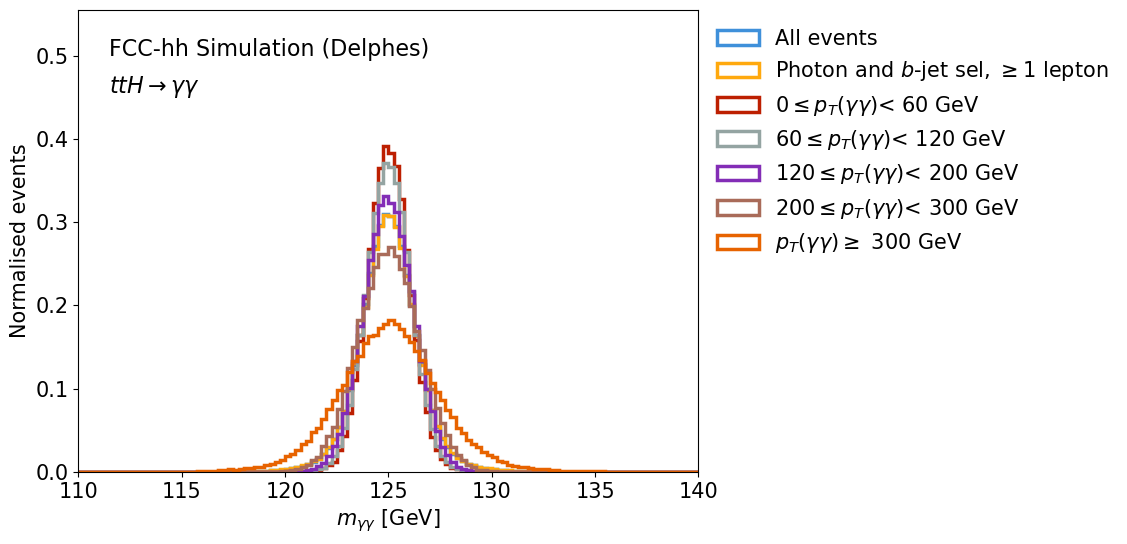

In [25]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
for i_sel, sel_key in enumerate(list(selection.keys())) :
    bin_values, bin_edges, _ = ax.hist(df[process_key][sel_key]["m_yy"], 
                                        weights=df[process_key][sel_key]["weight"],
                                       bins=120, range=(110,140),
                                       histtype='step', linewidth=2.5, color=color_sequence[i_sel],
                                       label=selection[sel_key], density=True)
    
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
#ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = "$m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')
#ax.set_yscale("log")
ax.set_xlim(110,140)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "myy_resolution"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

/tmp/elmazzeo/ipykernel_1090265/592123465.py:17: RuntimeWarning: invalid value encountered in scalar divide
  error = np.std(observable)/(len(df_all)-1)


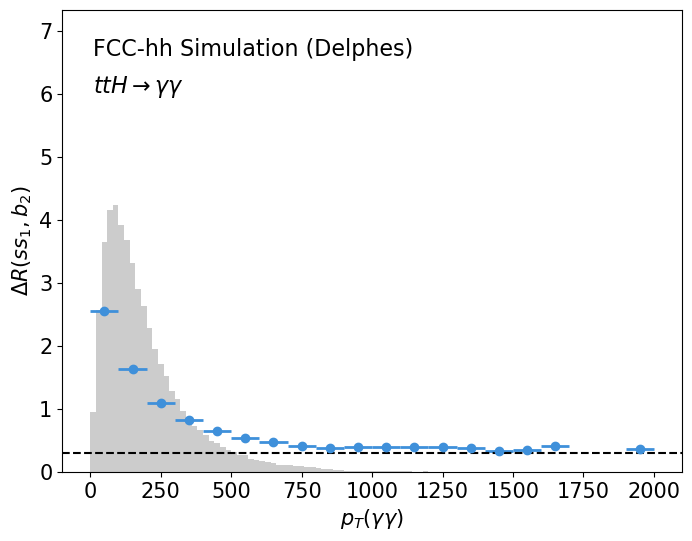

In [107]:
df3 = df1['ttHyy']['lep_channel'].copy()
PT_BINS = np.linspace(0, 2000., 21)
df3['pT_bin'] = np.digitize(np.abs(df3['pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df3[df3['pT_bin']==ibin]
    observable = df_all['DR_y_y'].copy()
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df3['pT_yy'], weights=df3["weight"]/df3["weight"].sum()*50,
        bins=100, range=(0,2000), histtype='stepfilled', color='grey', alpha=0.4)
ax.axhline(0.3, color='k', ls='--')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\Delta R(ss_1,b_2$)')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
plotname = "DR_bb_as_a_function_of_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

/tmp/elmazzeo/ipykernel_1090265/600109736.py:17: RuntimeWarning: invalid value encountered in scalar divide
  error = np.std(observable)/(len(df_all)-1)


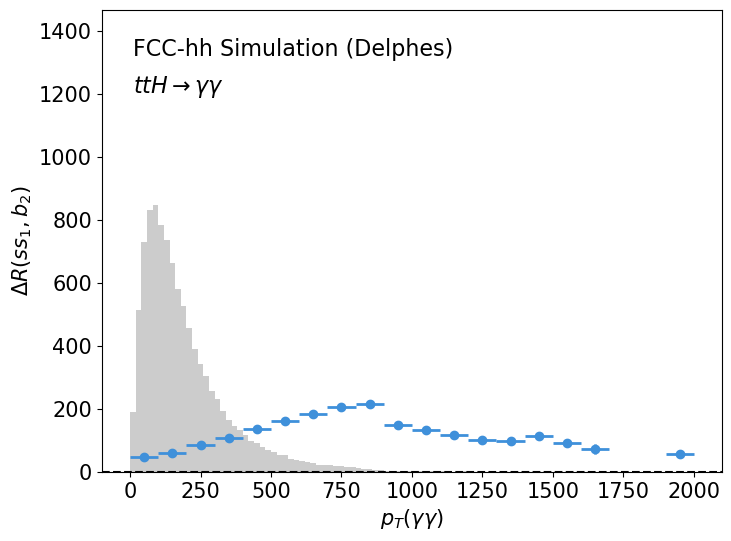

In [111]:
df3 = df1['ttHyy']['lep_channel'].copy()
PT_BINS = np.linspace(0, 2000., 21)
df3['pT_bin'] = np.digitize(np.abs(df3['pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df3[df3['pT_bin']==ibin]
    observable = df_all['pT_y2'].copy()
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df3['pT_yy'], weights=df3["weight"]/df3["weight"].sum()*10e3,
        bins=100, range=(0,2000), histtype='stepfilled', color='grey', alpha=0.4)
ax.axhline(0.3, color='k', ls='--')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\Delta R(ss_1,b_2$)')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
plotname = "DR_bb_as_a_function_of_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

In [ ]:
rdf = ROOT.RDataFrame(